# Assignment IV: Optimization with Parallelization

## Task 1.1

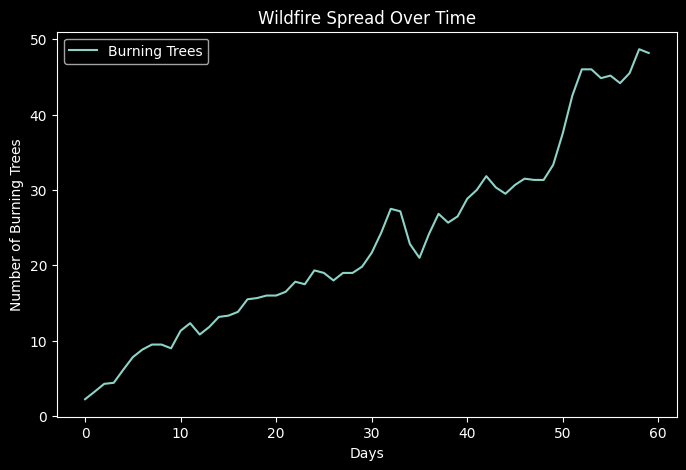

In [6]:
import multiprocessing
import numpy as np
import matplotlib.pyplot as plt

from wildfire import simulate_wildfire, DAYS

p = 8


def mp_wildfire():
    with multiprocessing.Pool(p) as pool:
        results = pool.starmap(simulate_wildfire, [() for _ in range(p)])
        for r in results:
            l = len(r)
            if l < DAYS:
                r.extend([np.nan] * (DAYS - l))
        return np.nanmean(results, axis=0)


avg = mp_wildfire()
plt.figure(figsize=(8, 5))
plt.plot(range(len(avg)), avg, label="Burning Trees")
plt.xlabel("Days")
plt.ylabel("Number of Burning Trees")
plt.title("Wildfire Spread Over Time")
plt.legend()
plt.show()

## Task 1.2

http://127.0.0.1:8787/status


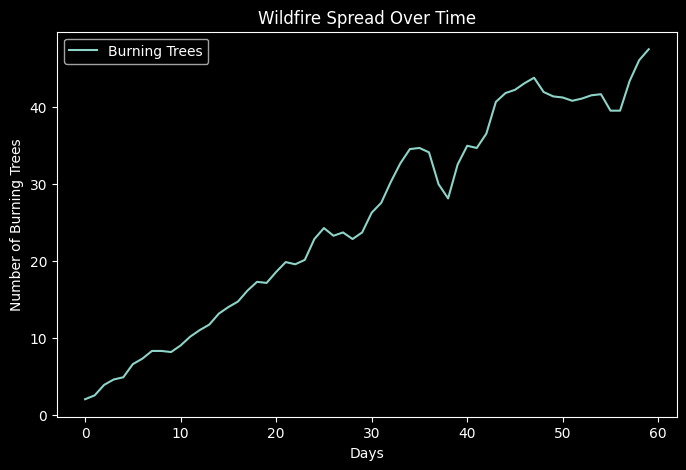

In [1]:
import dask
import numpy as np
import dask.array as da
import matplotlib.pyplot as plt
from dask.distributed import Client, LocalCluster
from wildfire import simulate_wildfire, DAYS

p = 8


def dask_wildfire():
    cluster = LocalCluster(n_workers=p)
    client = Client(cluster)
    print(client.dashboard_link)

    delayed_wildfire = dask.delayed(simulate_wildfire)
    results = [delayed_wildfire() for _ in range(p)]

    results = [dask.delayed(lambda x: np.array(x + [np.nan] * (DAYS - len(x)), dtype=float))(r) for r in results]
    darrs = [da.from_delayed(r, shape=(DAYS,), dtype=float) for r in results]
    stacked = da.stack(darrs, axis=0)
    mean = da.nanmean(stacked, axis=0)
    avg = mean.compute()

    client.close()
    cluster.close()
    return avg


avg = dask_wildfire()
plt.figure(figsize=(8, 5))
plt.plot(range(len(avg)), avg, label="Burning Trees")
plt.xlabel("Days")
plt.ylabel("Number of Burning Trees")
plt.title("Wildfire Spread Over Time")
plt.legend()
plt.show()